# Stock Market Project — Exploratory Data Analysis

This notebook performs exploratory data analysis for a multi-stock daily price dataset.

## Goals
- inspect data quality issues such as missing values and duplicates
- study price and return distributions
- check volatility clustering and extreme market moves
- compare stock-by-stock behavior
- explore relationships between engineered features and the prediction target
- compare important market regimes such as the 2020 crash and the 2022 drawdown

This EDA will help motivate later modeling choices for forecasting, survival analysis, and ranking.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import zscore

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

### 1. Load data

In [3]:
data_path = Path("../02_magic/01_data/raw/stock_prices.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (40351, 8)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL


### 2. Basic cleaning and setup

We first standardize column types and sort the data by ticker and date.

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

required_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

price_col = "Adj Close" if "Adj Close" in df.columns else "Close"

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL


### 3. Feature engineering for EDA

These features will also be useful later for modeling:
- daily return
- lagged returns
- rolling volatility
- daily volume change
- next-day return target

In [5]:
df_eda = df.copy()

if "Return_1d" not in df_eda.columns:
    df_eda["Return_1d"] = df_eda.groupby("Ticker")[price_col].pct_change(1)

if "Return_3d" not in df_eda.columns:
    df_eda["Return_3d"] = df_eda.groupby("Ticker")[price_col].pct_change(3)

if "Return_5d" not in df_eda.columns:
    df_eda["Return_5d"] = df_eda.groupby("Ticker")[price_col].pct_change(5)

if "Volatility_5d" not in df_eda.columns:
    df_eda["Volatility_5d"] = (
        df_eda.groupby("Ticker")["Return_1d"]
        .rolling(5)
        .std()
        .reset_index(level=0, drop=True)
    )

if "Volatility_20d" not in df_eda.columns:
    df_eda["Volatility_20d"] = (
        df_eda.groupby("Ticker")["Return_1d"]
        .rolling(20)
        .std()
        .reset_index(level=0, drop=True)
    )

if "Volume_Change_1d" not in df_eda.columns:
    df_eda["Volume_Change_1d"] = df_eda.groupby("Ticker")["Volume"].pct_change(1)

if "Target_Return_1d" not in df_eda.columns:
    df_eda["Target_Return_1d"] = (
        df_eda.groupby("Ticker")[price_col]
        .pct_change(1)
        .shift(-1)
    )

df_eda["Weekday"] = df_eda["Date"].dt.day_name()
df_eda["Month"] = df_eda["Date"].dt.month_name()

df_eda.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412385,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423469,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321294,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351558,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


### 4. Data overview

In [6]:
print("Rows, columns:", df_eda.shape)
print("\nTickers:", sorted(df_eda["Ticker"].unique()))
print("\nDate range:", df_eda["Date"].min().date(), "to", df_eda["Date"].max().date())

display(df_eda.info())
display(df_eda.describe(include="all").T.head(20))

Rows, columns: (40351, 17)

Tickers: ['AAPL', 'AMZN', 'GOOGL', 'HD', 'JNJ', 'JPM', 'META', 'MSFT', 'PG', 'XOM']

Date range: 2010-01-04 to 2026-04-15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40351 entries, 0 to 40350
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              40351 non-null  datetime64[ns]
 1   Open              40351 non-null  float64       
 2   High              40351 non-null  float64       
 3   Low               40351 non-null  float64       
 4   Close             40351 non-null  float64       
 5   Adj Close         40351 non-null  float64       
 6   Volume            40351 non-null  int64         
 7   Ticker            40351 non-null  object        
 8   Return_1d         40341 non-null  float64       
 9   Return_3d         40321 non-null  float64       
 10  Return_5d         40301 non-null  float64       
 11  Volatility_5d     40301 non-null  

None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,40351,NaN,NaN,NaN,2018-03-29 19:40:22.690887424,2010-01-04 00:00:00,2014-04-02 00:00:00,2018-04-05 00:00:00,2022-04-06 00:00:00,2026-04-15 00:00:00,NaN
Open,"40,351.000000",NaN,NaN,NaN,123.182981,5.296500,52.465000,93.120003,158.000000,791.150024,107.006336
High,"40,351.000000",NaN,NaN,NaN,124.384705,5.564500,52.959999,93.980003,159.511749,796.250000,108.147185
Low,"40,351.000000",NaN,NaN,NaN,121.972814,5.290000,51.875000,92.313499,156.440002,780.820007,105.800342
Close,"40,351.000000",NaN,NaN,NaN,123.215307,5.430500,52.459000,93.184998,158.004997,790.000000,106.995640
Adj Close,"40,351.000000",NaN,NaN,NaN,112.478807,5.430500,40.695883,77.246498,148.438156,788.148987,107.396103
Volume,"40,351.000000",NaN,NaN,NaN,"47,665,507.746921","1,093,900.000000","9,018,300.000000","19,520,600.000000","46,717,600.000000","1,880,998,000.000000","94,823,475.465405"
Ticker,40351,10,AAPL,4095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Return_1d,"40,341.000000",NaN,NaN,NaN,0.000786,-0.263901,-0.006909,0.000667,0.008686,0.296115,0.016967
Return_3d,"40,321.000000",NaN,NaN,NaN,0.002342,-0.303684,-0.011768,0.002552,0.016905,0.336477,0.028665


### Data overview

The dataset contains **40,351 observations across 17 columns** for **10 stocks**\
(AAPL, AMZN, GOOGL, HD, JNJ, JPM, META, MSFT, PG, XOM) covering **2010-01-04 to 2026-04-15**.

### 5. Missing values

Missing values are common in time-series feature engineering because rolling windows and lagged features naturally create NaNs at the beginning of each ticker history.

,Missing_Count,Missing_Pct
Volatility_20d,200,0.495651
Volatility_5d,50,0.123913
Return_5d,50,0.123913
Return_3d,30,0.074348
Return_1d,10,0.024783
Target_Return_1d,10,0.024783
Volume_Change_1d,10,0.024783


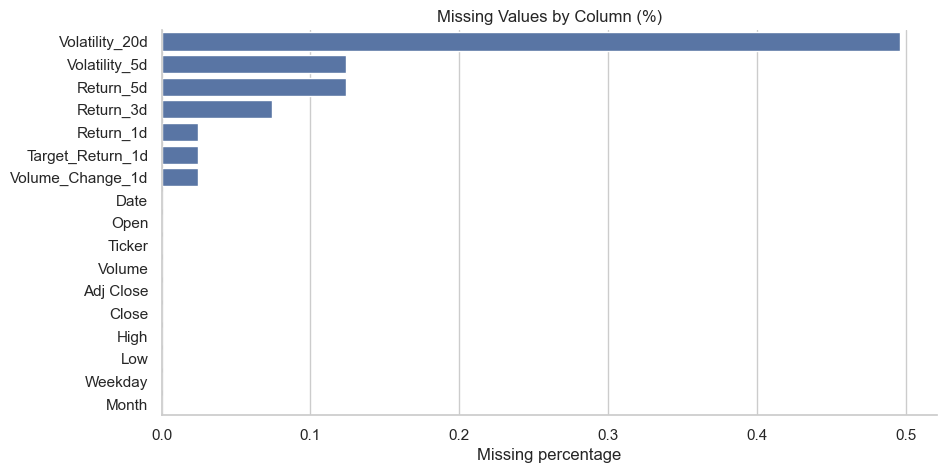

In [7]:
missing_summary = (
    df_eda.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)
missing_summary["Missing_Pct"] = 100 * missing_summary["Missing_Count"] / len(df_eda)
display(missing_summary[missing_summary["Missing_Count"] > 0])

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_summary.reset_index().rename(columns={"index": "Column"}),
    x="Missing_Pct",
    y="Column"
)
plt.title("Missing Values by Column (%)")
plt.xlabel("Missing percentage")
plt.ylabel("")
plt.show()

### Missing values

Only few missing values appear only in engineered features such as **returns, rolling volatility, and volume change**\
with the highest share still only about **0.5%** for `Volatility_20d`. This pattern is expected because lagged returns

### 6. Duplicates

We check both exact duplicates and ticker-date duplicates, since each ticker should normally have only one row per trading day.

In [8]:
exact_duplicates = df_eda.duplicated().sum()
ticker_date_duplicates = df_eda.duplicated(subset=["Ticker", "Date"]).sum()

print("Exact duplicate rows:", exact_duplicates)
print("Ticker-Date duplicate rows:", ticker_date_duplicates)

if ticker_date_duplicates > 0:
    display(
        df_eda[df_eda.duplicated(subset=["Ticker", "Date"], keep=False)]
        .sort_values(["Ticker", "Date"])
        .head(20)
    )

Exact duplicate rows: 0
Ticker-Date duplicate rows: 0


Hippy happy - no dups :)

### 7. Adjusted close over time by ticker

This chart will helps us to understand long-run price trends and major market drawdowns across stocks.

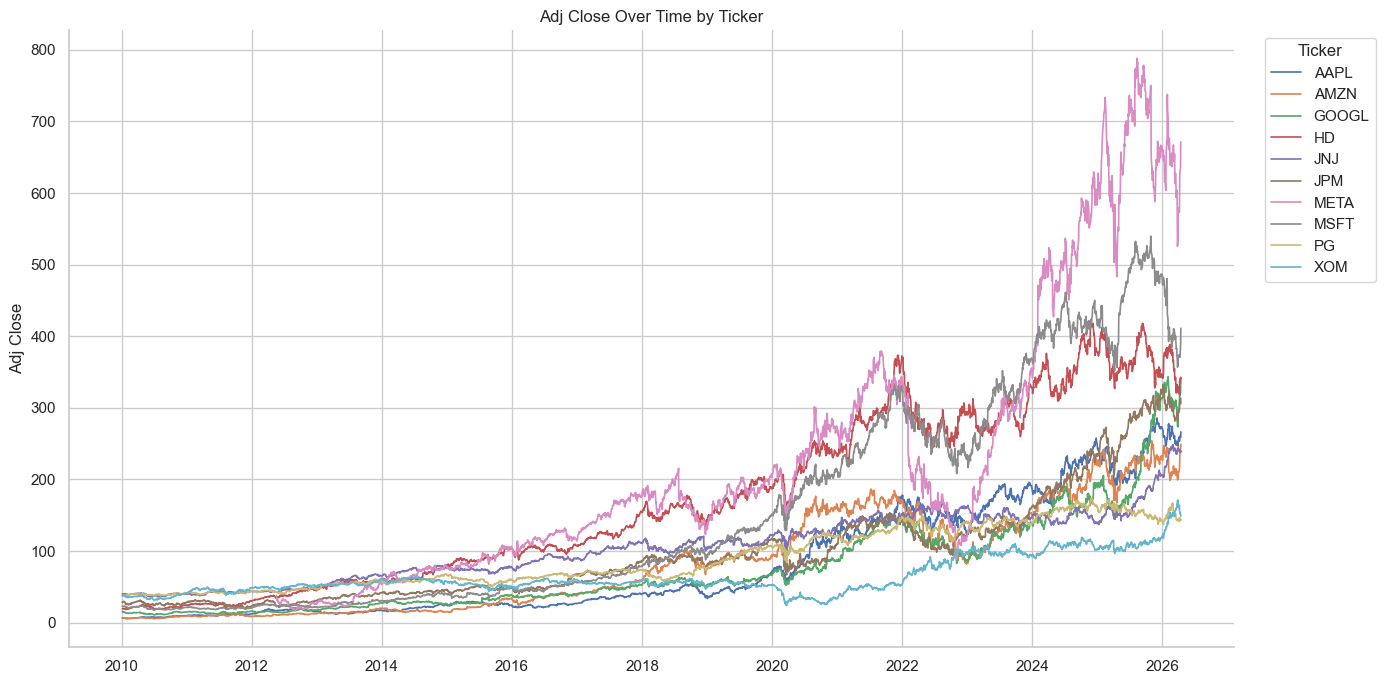

In [9]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_eda, x="Date", y=price_col, hue="Ticker", linewidth=1.2)
plt.title(f"{price_col} Over Time by Ticker")
plt.xlabel("")
plt.ylabel(price_col)
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The stocks in the current sample exhibit strong long-run growth, but the magnitude and smoothness of that growth\
differ meaningfully across tickers.

**Note**

META enters the dataset later than the other stocks. For strict cross-stock comparisons\
or pooled modeling, it may be preferable to use the common overlapping sample period.

### 8. Price and return distributions

Price levels due to long-term growth are usually right-skewed, while daily returns are centered near zero but often have fat tails and outliers.

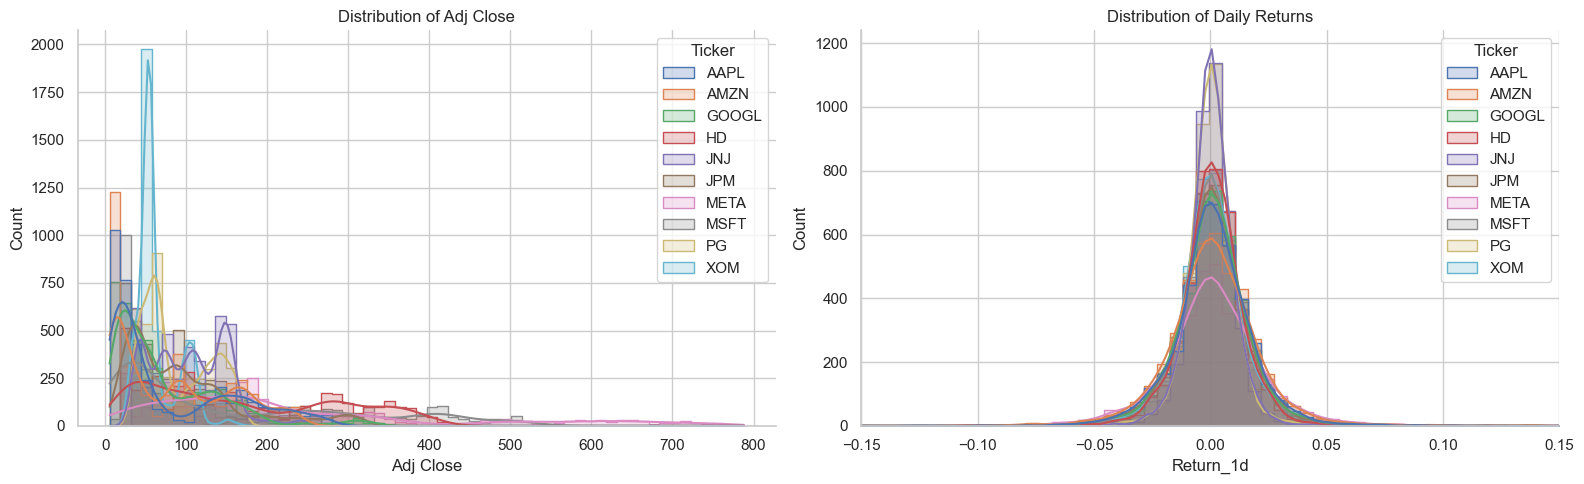

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df_eda, x=price_col, hue="Ticker", bins=60, kde=True, ax=axes[0], element="step")
axes[0].set_title(f"Distribution of {price_col}")

sns.histplot(
    data=df_eda.dropna(subset=["Return_1d"]),
    x="Return_1d",
    hue="Ticker",
    bins=100,
    kde=True,
    ax=axes[1],
    element="step"
)
axes[1].set_title("Distribution of Daily Returns")
axes[1].set_xlim(-0.15, 0.15)

plt.tight_layout()
plt.show()

Adjusted close prices are strongly right-skewed, which reflects long-term growth and\
higher price levels reached only in later years. Daily returns are centered near zero,\
but fat tails are visible, indicating occasional extreme moves and non-normal return behavior.

### 9. Boxplots of returns by ticker

This chart makes it easier to compare return spread across stocks and see which ones have more variable daily returns.

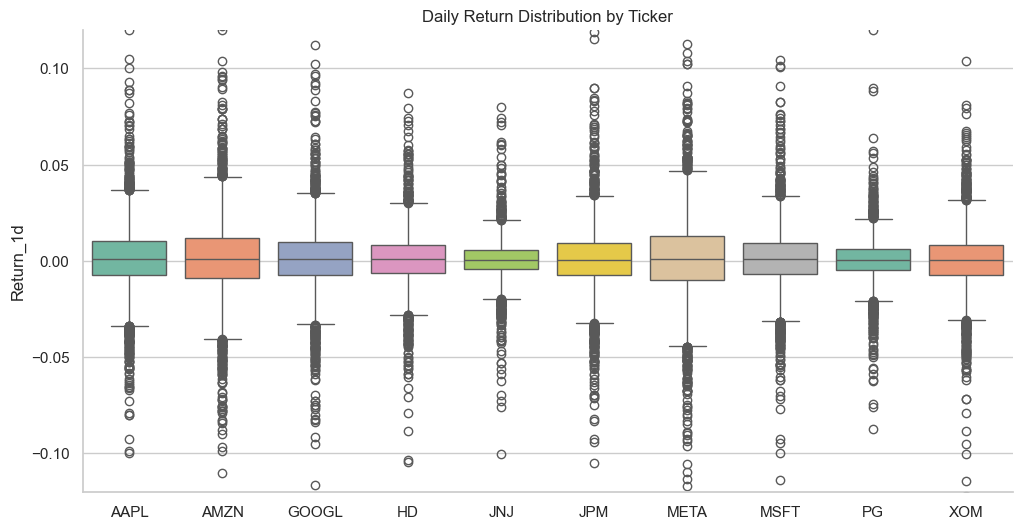

In [11]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_eda.dropna(subset=["Return_1d"]),
    x="Ticker",
    y="Return_1d",
    hue="Ticker",
    palette="Set2",
    legend=False
)

plt.title("Daily Return Distribution by Ticker")
plt.xlabel("")
plt.ylabel("Return_1d")
plt.ylim(-0.12, 0.12)
plt.show()

The boxplots show that daily returns are centered close to zero across the current stock set,\
meaning their typical daily moves are usually small. At the same time, the tickers\
still show many outliers on both sides, so dispersion differs across stocks.

### 10. Rolling 20-day

Rolling volatility is useful for identifying spiking periods in the market.

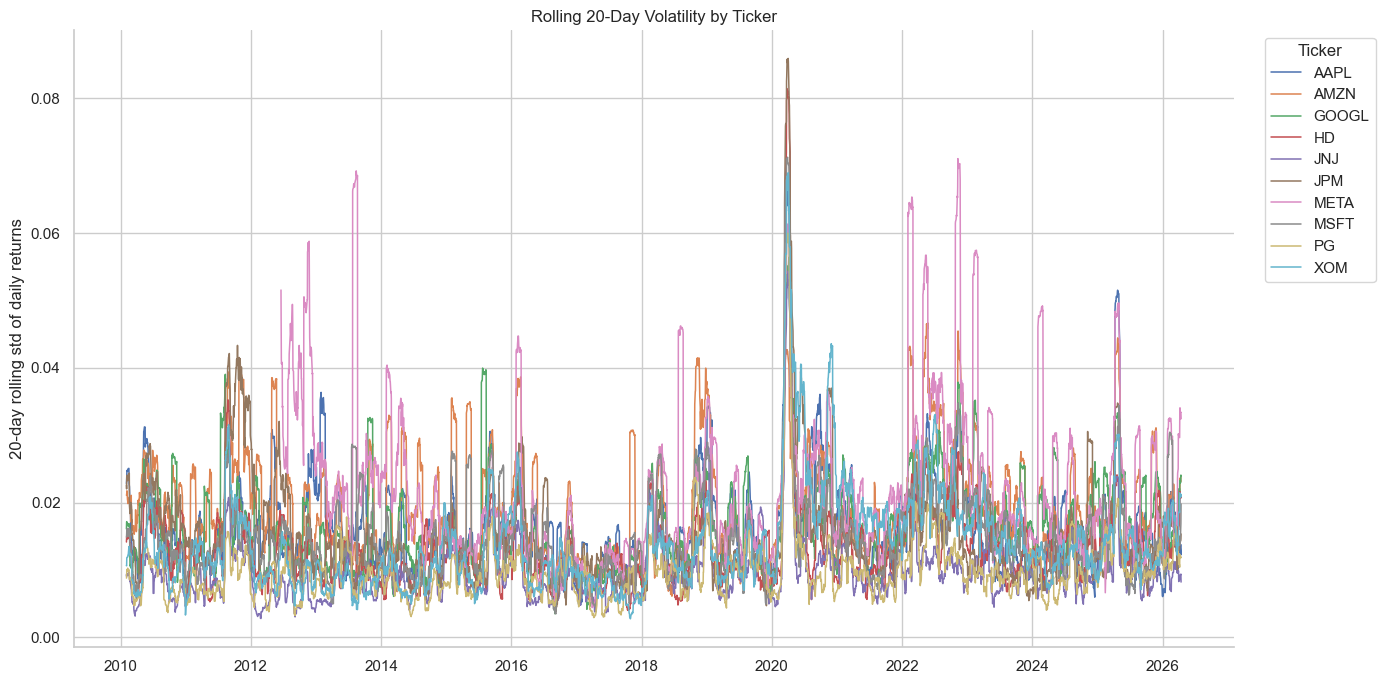

In [12]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_eda, x="Date", y="Volatility_20d", hue="Ticker", linewidth=1.1)
plt.title("Rolling 20-Day Volatility by Ticker")
plt.xlabel("")
plt.ylabel("20-day rolling std of daily returns")
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Most stocks still move in broadly similar directions, especially during stressed periods.\
The biggest common moves appear around major market shocks, where cross-stock behavior becomes much more synchronized.

### 11. Volatility clustering

Financial returns often show volatility clustering, meaning large moves tend to be followed by large moves, even if the direction changes.

,,"Corr(abs_return_t, abs_return_t-1)"
Ticker,,
AAPL,Abs_Return_1d,0.192853
AMZN,Abs_Return_1d,0.150347
GOOGL,Abs_Return_1d,0.127391
HD,Abs_Return_1d,0.246367
JNJ,Abs_Return_1d,0.230139
JPM,Abs_Return_1d,0.303929
META,Abs_Return_1d,0.110400
MSFT,Abs_Return_1d,0.215531
PG,Abs_Return_1d,0.248879


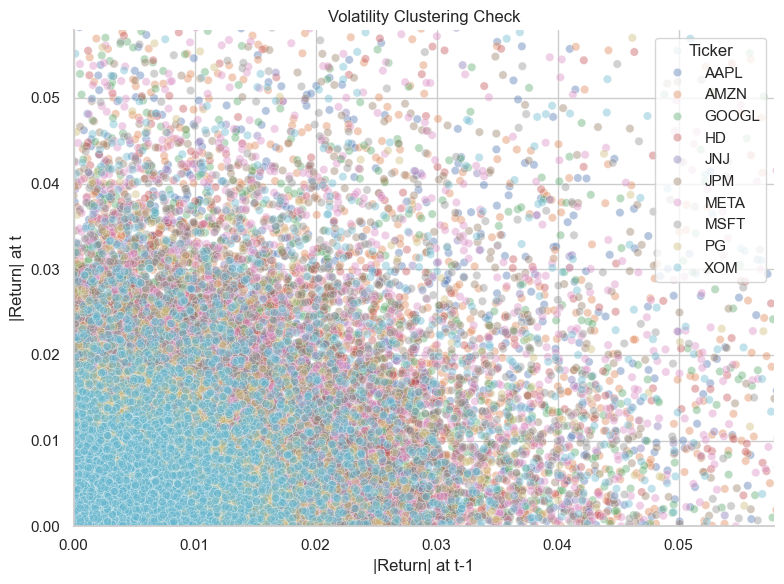

In [13]:
vol_cluster_df = df_eda[["Ticker", "Date", "Return_1d"]].copy()
vol_cluster_df["Abs_Return_1d"] = vol_cluster_df["Return_1d"].abs()
vol_cluster_df["Lag_Abs_Return_1d"] = vol_cluster_df.groupby("Ticker")["Abs_Return_1d"].shift(1)

display(
    vol_cluster_df.groupby("Ticker")[["Abs_Return_1d", "Lag_Abs_Return_1d"]]
    .corr()
    .iloc[0::2, -1]
    .to_frame("Corr(abs_return_t, abs_return_t-1)")
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=vol_cluster_df.dropna(),
    x="Lag_Abs_Return_1d",
    y="Abs_Return_1d",
    hue="Ticker",
    alpha=0.4
)
plt.title("Volatility Clustering Check")
plt.xlabel("|Return| at t-1")
plt.ylabel("|Return| at t")
plt.xlim(0, vol_cluster_df["Lag_Abs_Return_1d"].quantile(0.99))
plt.ylim(0, vol_cluster_df["Abs_Return_1d"].quantile(0.99))
plt.tight_layout()
plt.show()

The results suggest **mild volatility clustering** across the current stock set. This means that large\
price moves are more likely to be followed by another large move, although the strength of that effect\
is not the same for every ticker.

### 12. Outliers and anomalies

We flag unusually large daily moves using ticker-level z-scores and also inspect the largest absolute returns directly.

Z-score was used to identify unusually large daily returns relative to each stock’s typical return behavior.

In [14]:
anomaly_df = df_eda.dropna(subset=["Return_1d"]).copy()

anomaly_df["Return_Zscore"] = (
    anomaly_df.groupby("Ticker")["Return_1d"]
    .transform(lambda s: zscore(s, nan_policy="omit"))
)

anomaly_df["Anomaly_Flag"] = anomaly_df["Return_Zscore"].abs() > 3

anomaly_summary = (
    anomaly_df.groupby("Ticker")["Anomaly_Flag"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "Anomaly_Count", "mean": "Anomaly_Rate"})
)

display(anomaly_summary)

largest_moves = (
    anomaly_df.assign(Abs_Return=anomaly_df["Return_1d"].abs())
    .sort_values("Abs_Return", ascending=False)
    [["Date", "Ticker", "Return_1d", "Return_Zscore", "Volume"]]
    .head(20)
)

display(largest_moves)

,Anomaly_Count,Anomaly_Rate
Ticker,,
AAPL,57,0.013923
AMZN,62,0.015144
GOOGL,62,0.015144
HD,56,0.013679
JNJ,54,0.013190
JPM,61,0.014900
META,47,0.013448
MSFT,54,0.013190
PG,66,0.016121


,Date,Ticker,Return_1d,Return_Zscore,Volume
24866,2013-07-25,META,0.296115,11.778269,365457900
27014,2022-02-03,META,-0.263901,-10.582707,188119900
27198,2022-10-27,META,-0.245571,-9.850804,232316600
27264,2023-02-02,META,0.232824,9.251120,150475700
27515,2024-02-02,META,0.203176,8.067322,84707600
14851,2020-03-16,HD,-0.197938,-13.561765,12536600
24680,2012-10-24,META,0.191282,7.592388,228949900
26126,2018-07-26,META,-0.189609,-7.616301,169803700
23040,2020-03-13,JPM,0.180125,10.334298,38543300
27072,2022-04-28,META,0.175936,6.979627,100890600


The anomaly check shows that extreme daily return events are still relatively rare, with rates staying around\
**1.3% to 1.6%** across the current stock set. The most extreme moves still cluster around stress periods,\
which suggests that these events are not evenly distributed through time.

### 13. Stock-by-stock behavior

Here we compare average return, median return, volatility, and average trading volume across stocks.

,Avg_Return_1d,Median_Return_1d,Std_Return_1d,Avg_Volatility_20d,Avg_Volume,Obs
Ticker,,,,,,
META,0.001136,0.000996,0.025048,0.022079,"28,080,760.726545",3495
AMZN,0.001096,0.000938,0.020682,0.019173,"80,279,573.064713",4094
AAPL,0.001067,0.000979,0.017709,0.016223,"216,015,919.609280",4094
GOOGL,0.000903,0.000927,0.017426,0.016072,"54,556,437.825641",4094
JPM,0.000732,0.000670,0.017361,0.015331,"18,518,903.125763",4094
MSFT,0.000834,0.000683,0.016157,0.014755,"35,301,500.073260",4094
XOM,0.000460,0.000239,0.015725,0.013864,"17,495,795.531136",4094
HD,0.000807,0.000766,0.014657,0.013099,"6,085,607.960928",4094
PG,0.000383,0.000497,0.010879,0.009784,"8,767,277.216117",4094


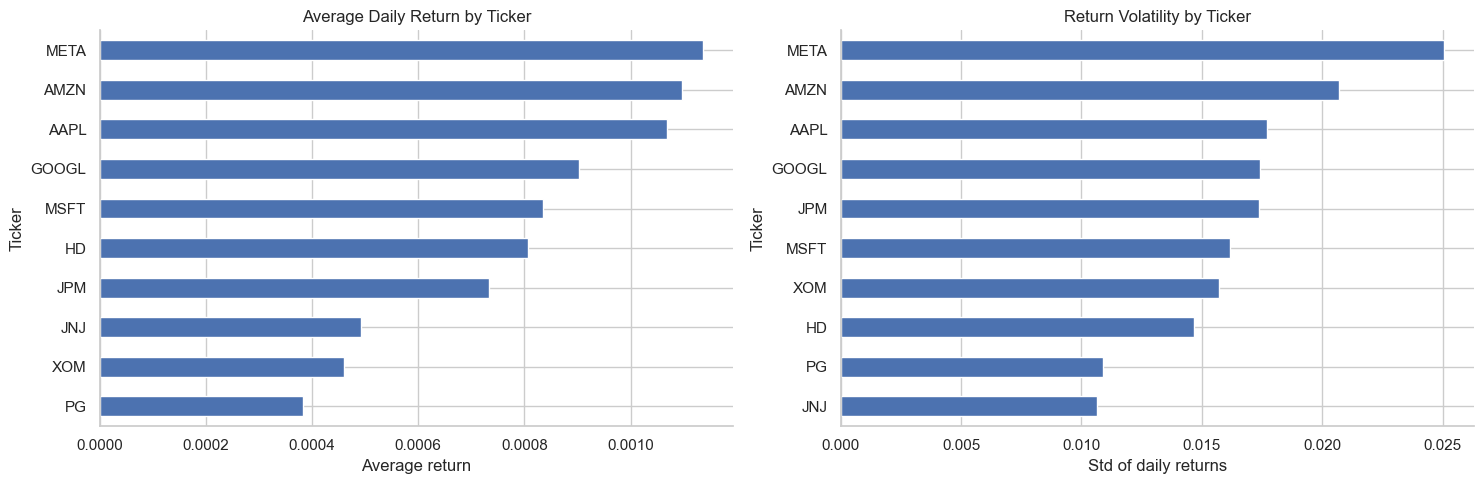

In [15]:
stock_summary = (
    df_eda.groupby("Ticker")
    .agg(
        Avg_Return_1d=("Return_1d", "mean"),
        Median_Return_1d=("Return_1d", "median"),
        Std_Return_1d=("Return_1d", "std"),
        Avg_Volatility_20d=("Volatility_20d", "mean"),
        Avg_Volume=("Volume", "mean"),
        Obs=("Return_1d", "count")
    )
    .sort_values("Std_Return_1d", ascending=False)
)

display(stock_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stock_summary["Avg_Return_1d"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Average Daily Return by Ticker")
axes[0].set_xlabel("Average return")

stock_summary["Std_Return_1d"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Return Volatility by Ticker")
axes[1].set_xlabel("Std of daily returns")

plt.tight_layout()
plt.show()

Some stocks in the current sample combine higher average daily returns with higher volatility, while others\
look more stable with lower return. This suggests a visible return-risk tradeoff across the dataset.

### 14. Calendar effects: weekday and month

These charts check whether average returns differ across weekdays or months.

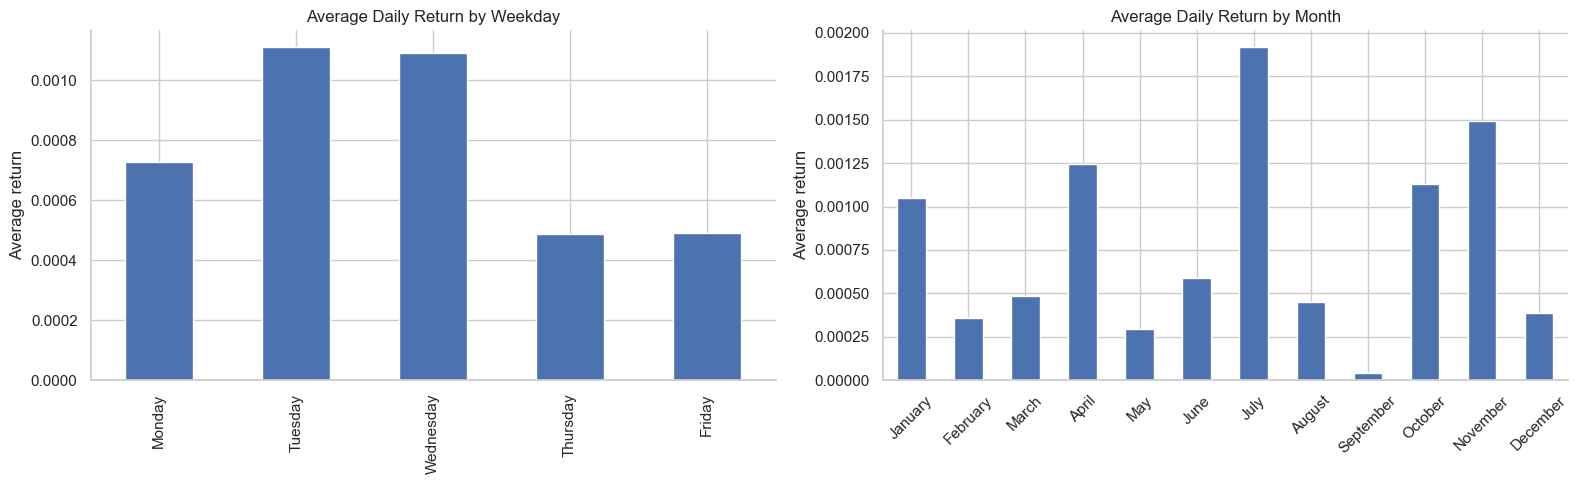

In [16]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

weekday_returns = (
    df_eda.groupby("Weekday")["Return_1d"]
    .mean()
    .reindex(weekday_order)
)

month_returns = (
    df_eda.groupby("Month")["Return_1d"]
    .mean()
    .reindex(month_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weekday_returns.plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Daily Return by Weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average return")

month_returns.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Daily Return by Month")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average return")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Wednesday** showing the strongest mean daily return and **Friday** the weakest.\
**July** stands out as the strongest month, while **February** and **September**\
are close to zero or slightly negative.

### 15. Correlations between engineered features and target

This helps show which engineered features are most related to next-day returns and may be useful for forecasting.

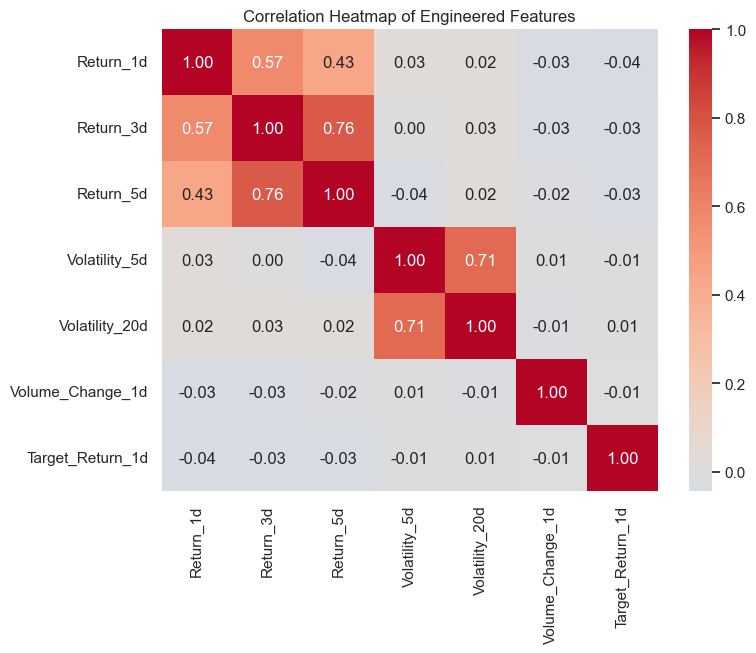

,Correlation_with_Target
Return_1d,-0.044476
Return_3d,-0.029755
Return_5d,-0.029171
Volatility_20d,0.014560
Volatility_5d,-0.008339
Volume_Change_1d,-0.007644


In [17]:
feature_cols = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d",
    "Target_Return_1d"
]

available_feature_cols = [col for col in feature_cols if col in df_eda.columns]

corr_df = df_eda[available_feature_cols].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

target_corr = (
    corr_matrix["Target_Return_1d"]
    .drop("Target_Return_1d")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Correlation_with_Target")
)

display(target_corr)

`Return_3d` and `Return_5d` suggests they capture similar short-term price patterns.\
However, their correlations with `Target_Return_1d` are all very weak and close to zero,\
meaning these simple features have limited linear relationship with next-day returns on their own.

### 16. Regime differences

We compare selected stress periods with the rest of the sample:
- 2020 crash
- 2022 drawdown
- other periods

,Avg_Return_1d,Median_Return_1d,Std_Return_1d,Avg_Volatility_20d,Obs
Regime,,,,,
2020 Crash,-0.000751,-0.004124,0.047612,0.042545,500
2022 Drawdown,-0.000739,-0.000556,0.024027,0.021982,2510
Other,0.000909,0.000717,0.015549,0.014040,37331


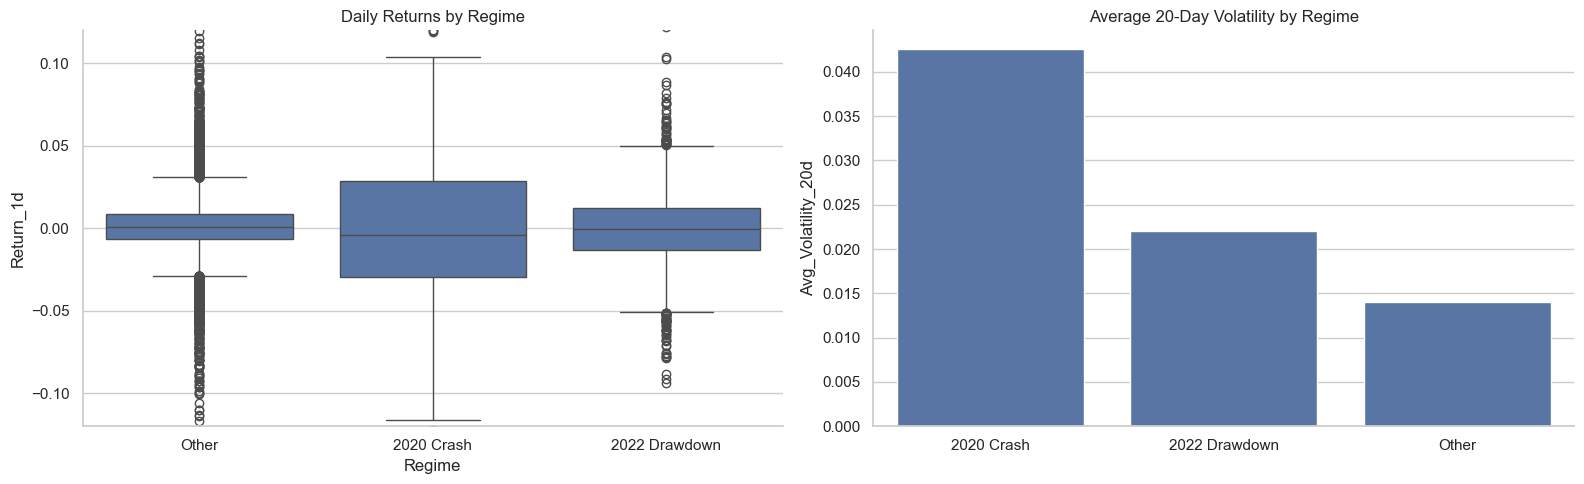

In [18]:
df_regime = df_eda.copy()

conditions = [
    (df_regime["Date"] >= "2020-02-20") & (df_regime["Date"] <= "2020-04-30"),
    (df_regime["Date"] >= "2022-01-01") & (df_regime["Date"] <= "2022-12-31"),
]

choices = ["2020 Crash", "2022 Drawdown"]
df_regime["Regime"] = np.select(conditions, choices, default="Other")

regime_summary = (
    df_regime.groupby("Regime")
    .agg(
        Avg_Return_1d=("Return_1d", "mean"),
        Median_Return_1d=("Return_1d", "median"),
        Std_Return_1d=("Return_1d", "std"),
        Avg_Volatility_20d=("Volatility_20d", "mean"),
        Obs=("Return_1d", "count")
    )
)

display(regime_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_regime.dropna(subset=["Return_1d"]), x="Regime", y="Return_1d", ax=axes[0])
axes[0].set_title("Daily Returns by Regime")
axes[0].set_ylim(-0.12, 0.12)

sns.barplot(
    data=regime_summary.reset_index(),
    x="Regime",
    y="Avg_Volatility_20d",
    ax=axes[1]
)
axes[1].set_title("Average 20-Day Volatility by Regime")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**2020 crash** having the highest volatility and widest return spread,\
**2022** was also more unstable than normal periods.\
In contrast, the **Other** period has lower volatility and more stable returns.

### 17. Normalized price paths during selected regimes

This gives a cleaner visual comparison of how each stock behaved during stress periods.

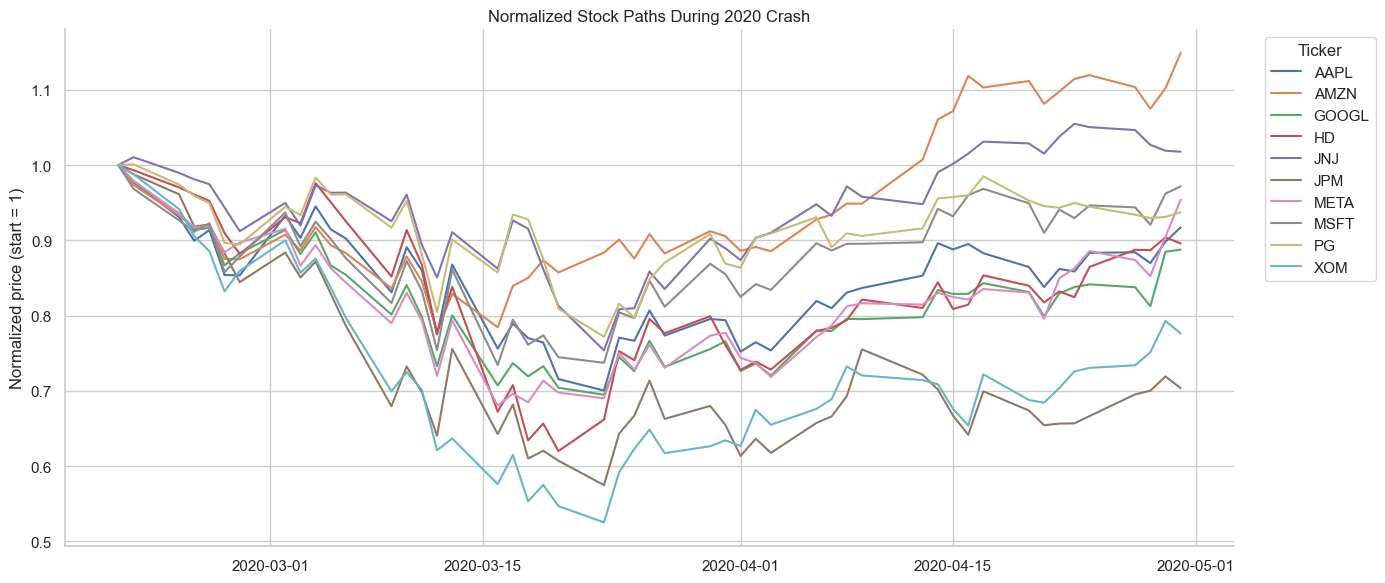

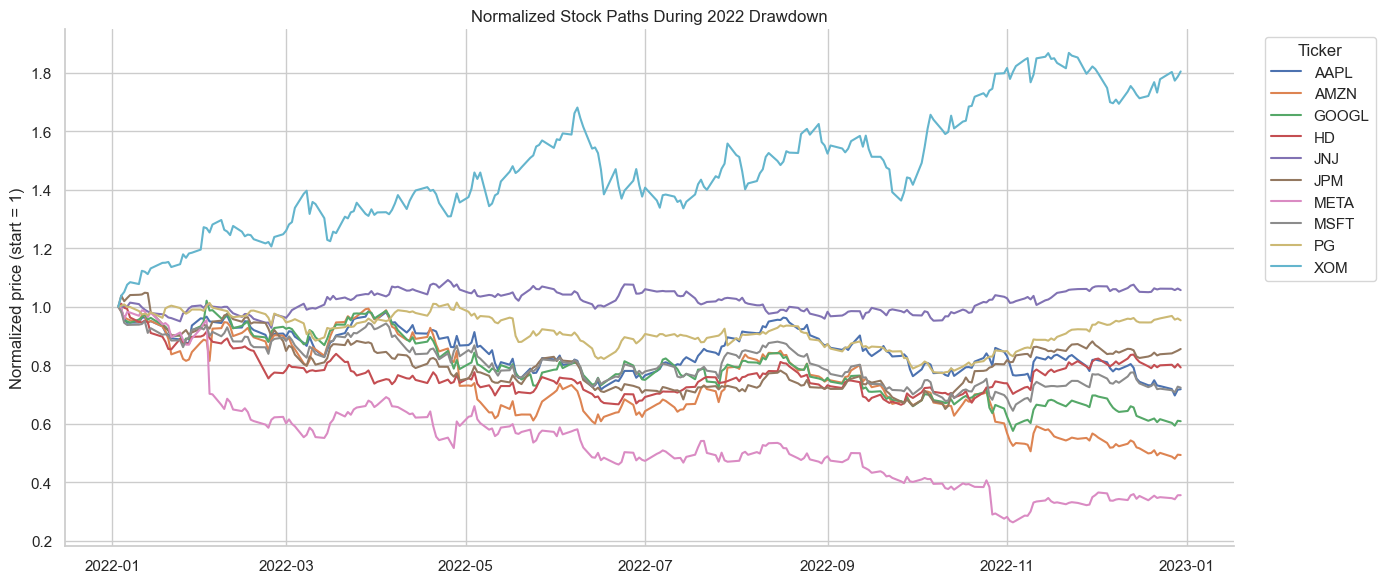

In [19]:
def plot_normalized_period(data, start_date, end_date, title):
    """
    Plot stock prices in a selected period after scaling each ticker to start at 1.

    This makes it easier to compare relative performance across stocks, because
    all lines begin from the same starting point instead of different price levels.
    """
    temp = data[(data["Date"] >= start_date) & (data["Date"] <= end_date)].copy()
    temp["Normalized_Price"] = temp.groupby("Ticker")[price_col].transform(lambda s: s / s.iloc[0])

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=temp, x="Date", y="Normalized_Price", hue="Ticker")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Normalized price (start = 1)")
    plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_normalized_period(df_eda, "2020-02-20", "2020-04-30", "Normalized Stock Paths During 2020 Crash")
plot_normalized_period(df_eda, "2022-01-01", "2022-12-31", "Normalized Stock Paths During 2022 Drawdown")

### Normalized price paths during selected regimes

During the **2020 crash**, all stocks dropped sharply, but the rebound was uneven across tickers.\
During the **2022 drawdown**, the decline was more prolonged and uneven, showing that some stocks\
held up better while others experienced much deeper losses.

### Key EDA takeaways

1. The dataset is clean, and missing values come mainly from lagged and rolling features.

2. Daily returns are centered near zero but show fat tails and extreme moves.

3. Volatility changes over time and tends to cluster during stressed periods.

4. Stocks differ in risk-return behavior, and the spread in volatility is clearly visible across tickers.

5. Market regimes such as 2020 and 2022 look meaningfully different from normal periods.

In [20]:
save_path = Path("../02_magic/01_data/raw/df_eda.csv")
df_eda.to_csv(save_path, index=False)

print(f"Saved to: {save_path.resolve()}")

Saved to: C:\Users\Nitro\Desktop\Turing College\DS\3rd Module\3rd project\02_magic\01_data\raw\df_eda.csv
